In [152]:
import importlib
import NeuralNetwork

importlib.reload(NeuralNetwork)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, random_split, Subset
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np

In [153]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"CUDA is available. Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA not available. Using CPU.")

CUDA not available. Using CPU.


In [154]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [155]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
print(f"train size: {train_size}, val size: {val_size}, test size: {len(test_dataset)}")

train size: 192000, val size: 48000, test size: 40000


In [156]:
# Create a DataLoader for batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [157]:
# Create model and train
model = NeuralNetwork(hidden_sizes=[512, 256, 128], device=device)

In [ ]:
model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=10)

Epoch 4/10:   6%|▌         | 217/3750 [00:02<00:41, 84.63it/s] 

In [ ]:
train_acc = model.accuracy(train_loader)
val_acc = model.accuracy(val_loader)
test_acc = model.accuracy(test_loader)

100%|██████████| 625/625 [00:04<00:00, 134.47it/s]


In [ ]:
print(f"Train: {(train_acc*100):.2f}%, Validation: {(val_acc*100):.2f}%, Test: {(test_acc*100):.2f}%")

Train: 96.63%, Validation: 96.36%, Test: 96.48%


In [ ]:
layer_data = model.get_layer_data(train_loader)
for layer_name, data in layer_data.items():
    print(f"{layer_name} activations has shape: {data['post_activation'].shape}")

In [ ]:
preds = model.predict(test_loader).cpu()

y_true = []
for _, y_batch in test_loader:
    y_true.append(y_batch)
y_true = torch.cat(y_true)

100%|██████████| 625/625 [00:04<00:00, 138.45it/s]


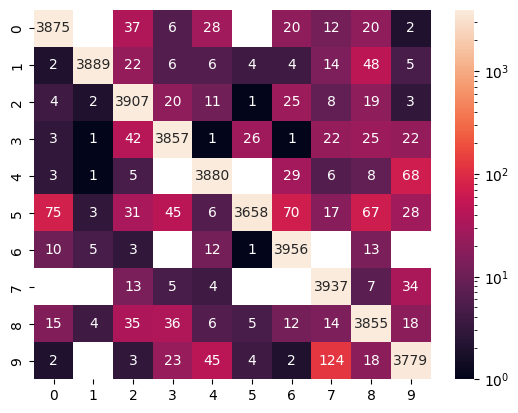

In [ ]:
from matplotlib.colors import LogNorm

cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, norm=LogNorm(), annot=True, fmt='d')
plt.show()

## Prune Neurons and Retrain

In [ ]:
model.prune_hidden_neurons(train_loader)

In [ ]:
model.train_model(train_loader, val_loader, epochs=5)

Epoch 5/5: 100%|██████████| 3750/3750 [00:40<00:00, 93.28it/s] 


,train_loss,val_loss,val_acc
epoch,,,
1,0.133288,0.124286,0.967583
2,0.129346,0.120360,0.967688
3,0.130910,0.120650,0.968063
4,0.131228,0.130083,0.967646
5,0.128881,0.130105,0.965896


In [ ]:
train_acc = model.accuracy(train_loader)
val_acc = model.accuracy(val_loader)
test_acc = model.accuracy(test_loader)

100%|██████████| 625/625 [00:04<00:00, 154.16it/s]


In [ ]:
print(f"Train: {(train_acc*100):.2f}%, Validation: {(val_acc*100):.2f}%, Test: {(test_acc*100):.2f}%")

Train: 96.77%, Validation: 96.59%, Test: 96.66%


In [ ]:
layer_data = model.get_layer_data(train_loader)
for layer_name, data in layer_data.items():
    print(f"{layer_name} activations has shape: {data['post_activation'].shape}")

layer_0 activations has shape: torch.Size([192000, 410])
layer_1 activations has shape: torch.Size([192000, 205])
layer_2 activations has shape: torch.Size([192000, 103])
layer_3 activations has shape: torch.Size([192000, 10])
